# Phase Corection
### General Story:
We got the phase and magnitude of an averaged signal from Phase on the Fly, now we want to detect frequency for PLL locking. In our case what we want is to detect the frequency difference from our expected and change to match that

We are assuming that the register is giving us an average of the entire adc read such that:
$$tan^{-1}(\frac{I}{Q}) = tan^{-1}(\frac{\int cos(\omega t + \phi)}{\int cos(\omega t + \phi + \frac{\pi}{4})})$$

Where by using some math and trig identities you get:

$$tan^{-1}(\frac{cos(\omega t + \phi)}{cos(\omega t + \phi + \frac{\pi}{4})}) = \phi$$

considering that 
$$\omega = \frac{\Delta \phi}{\Delta t}$$

we need two values of $\phi$ and the starting or stopping points of our read

In [ ]:
#imports
from qick import *
from qick.asm_v2 import *
%matplotlib inline
import matplotlib.pyplot as plt
import os
import git  # pip install gitpython


In [ ]:
#this block is for running a command on the RFsoC assuming you are 
#running one of the jupyter notebooks on the device but from a separate computer/visual studio code:

dir = os.getcwd()
print(dir)
print(os.listdir())
# print(os.getcwd())
# os.system("pip install gitpython")

In [ ]:
#this will pull from the github to make sure you have the most current updates

import git  # pip install gitpython
print(os.listdir())
if 'amo_qick' in os.listdir():
        print("getting into fork")
        os.chdir('amo_qick')
dir = os.getcwd()
print(dir)
g = git.cmd.Git(dir)
g.pull()

In [243]:


#This line is to sync to an external clock which needs to be 10 Mhz
#this line currently loads tproc1 firmware and is just to make sure everything is loaded properly
#soc = QickSoc(external_clk=True)

dir = os.getcwd()
print(dir)
#this line downloads the new hardware (just make sure thats what you want)
#soc = QickSoc()
#soc = QickSoc(bitfile =f'{dir}/tests/d_1.bit', download=True)
#as of Jan 2026: 
#rfsoc_board = most recently published bit, 
# ADC_0 = Self built file that connects adc port 0 to tproc 1
# d_1 = self built that puts a cordic loop on adc port 0 for phase analysis 
soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/d_1.bit', download=True)
soccfg = soc
print(soccfg)


/home/xilinx/jupyter_notebooks/amo_qick
QICK running on ZCU216, software version 0.2.388

Firmware configuration (built Fri Apr  3 16:28:09 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, o

#### Uncorrected from Laser

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: 118.85937329694407
buffered readout: [-29828.  54124.]
feedback readout: [     12560 1156764220]


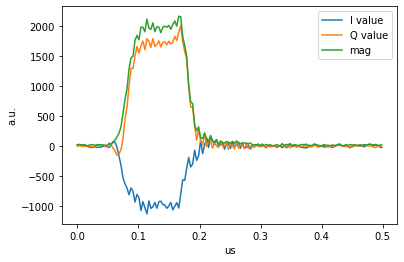

In [306]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': .9,
          'read_wait': 0.1,
          'ro_len': .5,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

### Uncorrected reference from different RF port
This isnt technically perfect but a good starting spot to see if we can correct to a specific phase value


In [ ]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 0.45,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

Lets see if we can correct to a static phase value. The following code is naive and should take forever to run. This is because of phase wrap around along with very small step sizes

In [292]:
objective = 0
step = 500
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        self.add_reg('step_size', None, QickParam(5))
        self.add_reg('neg_step_size', None, QickParam(-5))
        self.add_reg('threshold', None, QickParam(100000))

        
    def _body(self, cfg):
        
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_and_jump(cfg['ro_ch'],'Q', 0,'<', 'add')
        self.jump('sub')


        self.label('add')
        self.inc_reg('w_phase', 'step_size')
        self.cond_jump('finish', 's_port_h','NS', '+','threshold')
        self.jump('beginning')

        self.label('sub')
        self.inc_reg('w_phase', 'neg_step_size')
        self.cond_jump('finish', 's_port_h','S', '-','threshold')
        self.jump('beginning')

        self.label('finish')


config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### ok naive doesn't work
Lets try to actually get a test here that provides something useful. First I will start with what the graph looks like if I sweep the phase from its most negative to most positive value

In [251]:
def phase_change(phase_range=(100,110), phase_division = 10, num_reps = 10):
    class ReadProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            
            self.declare_gen(ch=gen_ch, nqz=1)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

            self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                        style="const", 
                        freq=cfg['freq'], 
                        length=cfg['pulse_len'],
                        phase=cfg['pulse_phase'],
                        gain=cfg['gain'], 
                        )

            self.add_readoutconfig(ch=ro_ch, name="myro", freq=config['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
            # send the config to the dynamic RO
            self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
            
        def _body(self, cfg):
            self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.wait_auto(cfg['read_wait'])
            self.read_input(ro_ch=cfg['ro_ch'])
            self.write_dmem(addr=0, src='s_port_l')
            self.write_dmem(addr=1, src='s_port_h')

    

    # prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    # iq_list = prog.acquire(soc, rounds=1, progress=False)
    # phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
    # config['ro_phase'] = -phase_offset
    plt.figure()
    phase_span = np.linspace(phase_range[0], phase_range[1], phase_division)
    phasebyphase = []
    for i, phase in enumerate(phase_span):
        config = {'gen_ch': 1,
            'ro_ch': 0,
            'freq': 120,
            'trig_time': 0.40,
            'read_wait': 0.1,
            'ro_len': 0.1,
            'pulse_len': 0.025,
            'pulse_phase':phase,
            'ro_phase': 0,
            'gain': 0.5
            }
        phase_data = []
        for rep in range(num_reps):
            prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

            iq_list = prog.acquire_decimated(soc, progress = False, rounds=1)
            t = prog.get_time_axis(ro_index=0)

            phase_maybe = soc.read_mem(2,'dmem')
            
            mag = phase_maybe[0]
            phase_dif = phase_maybe[1]

            phase_data.append((phase_dif, mag))
            
        phasebyphase.append(phase_data)
    return phasebyphase
phase_range = (-180,180)
phase_division = 21
phasebyphase = phase_change(phase_range=phase_range, phase_division= 21, num_reps=300)

<Figure size 432x288 with 0 Axes>

6330


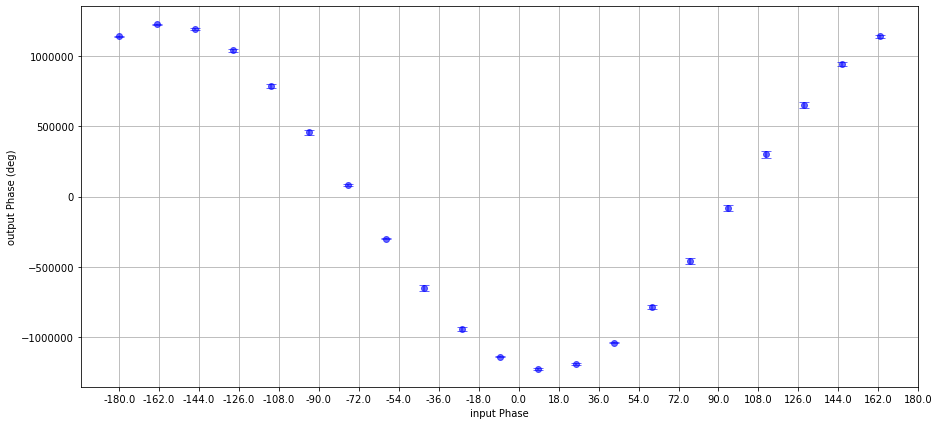

In [252]:

plt.figure(figsize = (15,7))

# Assuming phasebyphase is a list of arrays or lists, each with shape (N, 2)
print(phasebyphase[0][0][0])
for idx, phase_vals in enumerate(phasebyphase):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 0]*180

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to phases
phases = np.linspace(phase_range[0], phase_range[1], len(phasebyphase))
plt.xticks(np.linspace(0,21,21), phases)
plt.ylabel("output Phase (deg)")
plt.xlabel("input Phase")
plt.grid(True)
#plt.title("Phase Error by Frequency")


What I will do first is correct the phase of the RF reference to assure my looping algorithm is reasonable

  0%|          | 0/1 [00:00<?, ?it/s]

feedback readout: [2550 6340]


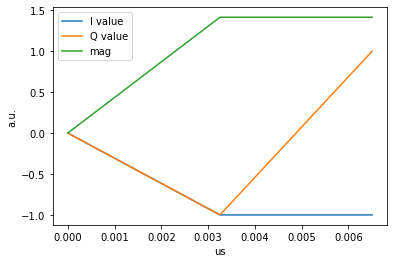

In [291]:
objective = 0
step = 500
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        self.add_reg('step_size', None, QickParam(5))
        self.add_reg('neg_step_size', None, QickParam(-5))
        self.add_reg('threshold', None, QickParam(5))

        
    def _body(self, cfg):
        
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_and_jump(cfg['ro_ch'],'Q', 0,'<', 'add')
        self.jump('sub')


        self.label('add')
        self.inc_reg('w_phase', 'step_size')
        self.cond_jump('finish', 's_port_h','NS', '+','threshold')
        self.jump('beginning')

        self.label('sub')
        self.inc_reg('w_phase', 'neg_step_size')
        self.cond_jump('finish', 's_port_h','S', '-','threshold')
        self.jump('beginning')

        self.label('finish')


config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
# print("phase offset:", phase_offset)

# print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

Seems to know when its locked to zero phase so lets see if we can add it back to the laser data and get it to lock

In [295]:
def phase_change(phase_range=(100,110), phase_division = 10, num_reps = 10):
    class ReadProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            
            self.declare_gen(ch=gen_ch, nqz=1)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

            self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                        style="const", 
                        freq=cfg['freq'], 
                        length=cfg['pulse_len'],
                        phase=cfg['pulse_phase'],
                        gain=cfg['gain'], 
                        )

            self.add_readoutconfig(ch=ro_ch, name="myro", freq=config['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
            # send the config to the dynamic RO
            self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
            
        def _body(self, cfg):
            self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
            self.wait_auto(cfg['read_wait'])
            self.read_input(ro_ch=cfg['ro_ch'])
            self.write_dmem(addr=0, src='s_port_l')
            self.write_dmem(addr=1, src='s_port_h')

    

    # prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    # iq_list = prog.acquire(soc, rounds=1, progress=False)
    # phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
    # config['ro_phase'] = -phase_offset
    plt.figure()
    phase_span = np.linspace(phase_range[0], phase_range[1], phase_division)
    phasebyphase = []
    for i, phase in enumerate(phase_span):
        config = {'gen_ch': 0,
            'ro_ch': 10,
            'freq': 120,
            'trig_time': 1,
            'read_wait': 0.1,
            'ro_len': 0.1,
            'pulse_len': 0.025,
            'pulse_phase':phase,
            'ro_phase': 0,
            'gain': 0.5
            }
        phase_data = []
        for rep in range(num_reps):
            prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

            iq_list = prog.acquire_decimated(soc, progress = False, rounds=1)
            t = prog.get_time_axis(ro_index=0)

            phase_maybe = soc.read_mem(2,'dmem')
            
            mag = phase_maybe[0]
            phase_dif = phase_maybe[1]

            phase_data.append((phase_dif, mag))
            
        phasebyphase.append(phase_data)
    return phasebyphase
phase_range = (-180,180)
phase_division = 21
phasebyphase = phase_change(phase_range=phase_range, phase_division= 21, num_reps=300)

<Figure size 432x288 with 0 Axes>

1263179494


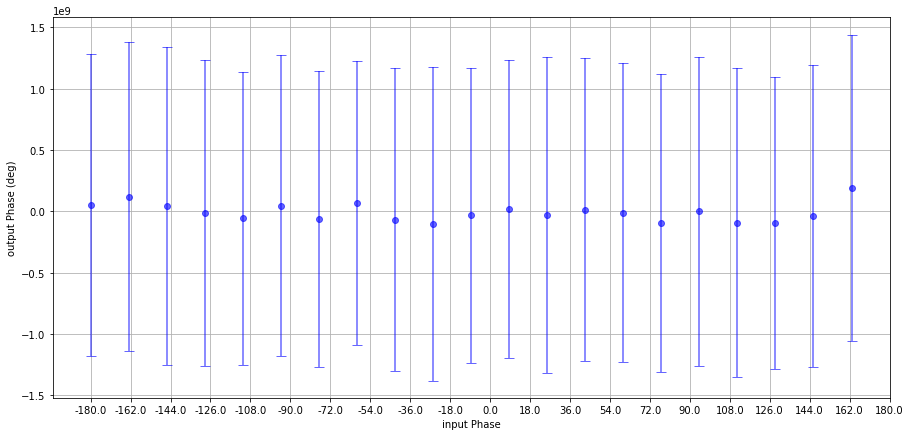

In [299]:

plt.figure(figsize = (15,7))

# Assuming phasebyphase is a list of arrays or lists, each with shape (N, 2)
print(phasebyphase[0][0][0])
for idx, phase_vals in enumerate(phasebyphase):

    phase_vals = np.asarray(phase_vals)
    value = phase_vals[:, 0]*180

    mean_val = np.mean(value)
    std_val = np.std(value)

    # Plot mean with error bar (std deviation)
    plt.errorbar(idx, mean_val, yerr=std_val, fmt='o', alpha=0.6, capsize=5, color='blue')

# Set x-ticks to correspond to phases
phases = np.linspace(phase_range[0], phase_range[1], len(phasebyphase))
plt.xticks(np.linspace(0,21,21), phases)
plt.ylabel("output Phase (deg)")
plt.xlabel("input Phase")
plt.grid(True)
#plt.title("Phase Error by Frequency")


We want to make an algorithm that makes the above graph look closer to our reference graph. First I would like to know how the phase changes in a specific pulse

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: 101.12473931632351
buffered readout: [-5994. 30482.]
feedback readout: [    36402 983259447]


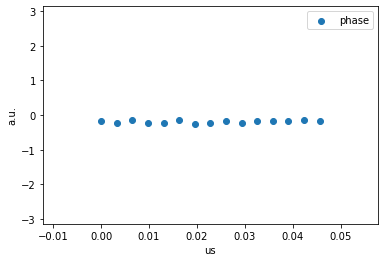

In [ ]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .05,
          'pulse_len': 0.1,
          'pulse_phase': 170,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.scatter(t, np.arctan2(iq_list[0][:,0], iq_list[0][:,1]), label="phase")
# plt.plot(t, iq_list[0][:,1], label="Q value")
# plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");
plt.ylim(-3.14, 3.14)

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

In [ ]:
threshold = 983259447
objective = 0
step = 500
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)

        self.add_reg('step_size', None, QickParam(5))
        self.add_reg('neg_step_size', None, QickParam(-5))
        self.add_reg('threshold', None, QickParam(threshold))

        
    def _body(self, cfg):
        
        
        
        self.label('beginning')
        #check and see if we have achieved phase = 0?
        
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        
        self.read_and_jump(cfg['ro_ch'],'Q', 0,'<', 'add')
        self.jump('sub')


        self.label('add')
        self.inc_reg('w_phase', 'step_size')
        self.cond_jump('finish', 's_port_h','NS', '+','threshold')
        self.jump('beginning')

        self.label('sub')
        self.inc_reg('w_phase', 'neg_step_size')
        self.cond_jump('finish', 's_port_h','S', '-','threshold')
        self.jump('beginning')

        self.label('finish')


config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
#print(prog)
iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))